# 05a — Graph Autoencoder (GAE / VGAE): Grafo de Miembros (M)Este notebook entrena un **Graph Autoencoder (GAE)** y un **Variational Graph Autoencoder (VGAE)** sobre el grafo de miembros `M` del dataset Meetup Tennessee, con el objetivo de detectar nodos estructuralmente anómalos.## ContextoEl grafo `M` contiene **11.371 nodos** (miembros con co-membresía) y **2.352.048 aristas** (en formato no dirigido, ambas direcciones). Cada nodo tiene **3 features** procedentes del feature engineering del notebook 04: `location_level`, `lat` y `lon`.A diferencia de un autoencoder clásico que reconstruye un vector de features, un Graph Autoencoder reconstruye la **estructura del grafo** — concretamente la matriz de adyacencia. La intuición es la siguiente: el modelo aprende a comprimir cada nodo en un embedding latente de baja dimensión y a partir de ese embedding intenta predecir qué nodos están conectados con qué nodos. Los nodos cuyas conexiones reales el modelo no consigue reconstruir bien — porque su patrón de vecindad es atípico — son candidatos a anomalía.## Esquema del notebook| Sección | Contenido ||---------|----------|| 0 | Imports y configuración || 1 | Carga del grafo y verificación || 2 | Split de aristas para entrenamiento || 3 | Arquitectura del GAE || 4 | Entrenamiento del GAE || 5 | Cálculo de anomaly scores (GAE) || 6 | Arquitectura y entrenamiento del VGAE || 7 | Anomaly scores (VGAE) || 8 | Comparativa GAE vs VGAE || 9 | Análisis de anomalías detectadas || 10 | Guardado de resultados |

## 0. Imports y configuración

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE, VGAE
from torch_geometric.utils import negative_sampling
from torch_geometric.transforms import RandomLinkSplit
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Carga del grafo M y verificaciónCargamos el objeto `Data` generado en el notebook 04. Verificamos que las dimensiones coinciden con lo esperado: 11.371 nodos, 2.352.048 aristas (cada arista no dirigida está duplicada en `edge_index`) y 3 features por nodo.También cargamos `meta_members` para poder interpretar los resultados — necesitaremos los nombres y ubicaciones de los miembros más anómalos en la fase final.

In [2]:
# Cargamos el objeto Data del grafo M
data_M = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_M.pt'), weights_only=False)

print(data_M)
print(f'\nNodos          : {data_M.num_nodes}')
print(f'Aristas (dirig.): {data_M.num_edges}')
print(f'Aristas únicas : {data_M.num_edges // 2}')
print(f'Features/nodo  : {data_M.num_node_features}')
print(f'Es no dirigido : {data_M.is_undirected()}')

Data(x=[11371, 3], edge_index=[2, 2352048], edge_weight=[2352048], member_ids=[11371])

Nodos          : 11371
Aristas (dirig.): 2352048
Aristas únicas : 1176024
Features/nodo  : 3
Es no dirigido : True


In [3]:
# Cargamos meta_members para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))
print(f'meta_members: {meta_members.shape}')
meta_members.head()

meta_members: (24590, 6)


,member_id,name,city,state,lat,lon
0,2069,Wesley Duffee-Braun,Brentwood,TN,36.00,-86.79
1,8386,Tim,Nashville,TN,36.07,-86.78
2,9205,Brenda,Brentwood,TN,36.00,-86.79
3,17903,Steve,Nashville,TN,36.13,-86.80
4,20418,Andrea Reynolds,Nashville,TN,36.17,-86.72


## 2. Split de aristas para entrenamientoA diferencia del aprendizaje supervisado clásico, en un GAE no separamos nodos en train/test — todos los nodos están presentes durante el entrenamiento porque la GCN del encoder necesita pasar mensajes por toda la estructura. Lo que sí separamos son las **aristas**: el modelo se entrena reconstruyendo un subconjunto de aristas y se valida con otro disjunto que no ha visto.`RandomLinkSplit` de PyG hace exactamente esto:- **`train`** (85%): aristas que el GCN usa para propagar mensajes y como ejemplos positivos del decoder.- **`val`** (5%): aristas reservadas para early stopping durante el entrenamiento.- **`test`** (10%): aristas para la evaluación final con AUC y AP.Para cada split positivo se generan ejemplos negativos del mismo tamaño — pares de nodos que **no** están conectados — porque el decoder aprende clasificación binaria: ¿existe arista o no?**Nota sobre el tamaño:** el grafo M tiene ~1.18M aristas únicas, que en CPU puede ser pesado. El entrenamiento se hace sobre todo el conjunto pero el cálculo de la pérdida en cada época usa muestreo negativo eficiente.

In [4]:
# RandomLinkSplit divide aristas en train/val/test
# is_undirected=True para preservar la simetría del grafo
# add_negative_train_samples=False porque negative_sampling lo hace dinámicamente cada época
transform = RandomLinkSplit(
    num_val=0.05,
    num_test=0.10,
    is_undirected=True,
    add_negative_train_samples=False,
    split_labels=True,
)

train_data, val_data, test_data = transform(data_M)

print('=== Split de aristas ===')
print(f'Train edges (positivos): {train_data.pos_edge_label_index.shape[1]}')
print(f'Val   edges (positivos): {val_data.pos_edge_label_index.shape[1]}')
print(f'Val   edges (negativos): {val_data.neg_edge_label_index.shape[1]}')
print(f'Test  edges (positivos): {test_data.pos_edge_label_index.shape[1]}')
print(f'Test  edges (negativos): {test_data.neg_edge_label_index.shape[1]}')

# Movemos los datos al device
train_data = train_data.to(device)
val_data   = val_data.to(device)
test_data  = test_data.to(device)

=== Split de aristas ===
Train edges (positivos): 999621
Val   edges (positivos): 58801
Val   edges (negativos): 58801
Test  edges (positivos): 117602
Test  edges (negativos): 117602


## 3. Arquitectura del GAE### 3.1 Fundamento teóricoUn Graph Autoencoder (Kipf & Welling, 2016) consta de dos componentes:**Encoder.** Una GCN de dos capas que mapea cada nodo a un embedding latente:$$Z = \text{GCN}(X, A) = \tilde{A} \cdot \sigma(\tilde{A} X W_0) \cdot W_1$$donde $\tilde{A}$ es la matriz de adyacencia normalizada con self-loops, $X$ es la matriz de features de los nodos y $W_0, W_1$ son matrices de pesos aprendibles. La primera capa proyecta de la dimensión de entrada (3) a una dimensión oculta, aplica ReLU, y la segunda capa proyecta a la dimensión latente final.**Decoder.** Una operación de producto interno entre embeddings, seguida de sigmoide:$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$La intuición es geométrica: dos nodos conectados tendrán embeddings con producto interno alto (similares en el espacio latente), y dos nodos no conectados tendrán producto interno bajo. El decoder no tiene parámetros aprendibles propios — toda la información se encuentra en los embeddings.### 3.2 Hiperparámetros elegidos| Hiperparámetro | Valor | Justificación ||---|---|---|| Dimensión oculta | 32 | Tamaño habitual en la literatura para grafos de este tamaño || Dimensión latente | 16 | Lo bastante baja para forzar compresión, suficiente para 11k nodos || Dropout | 0.2 | Regularización moderada || Optimizador | Adam | Estándar para GAEs || Learning rate | 0.01 | Valor por defecto del paper original || Épocas | 200 | Con early stopping basado en val AUC |La elección de dimensiones pequeñas (16-32) es deliberada: una dimensión latente demasiado alta permitiría al modelo memorizar el grafo entero y la reconstrucción sería perfecta para todos los nodos — perdiendo así la capacidad de discriminar anomalías.

In [5]:
class GCNEncoder(nn.Module):
    """
    Encoder GCN de dos capas para el GAE.
    Mapea features de entrada a embeddings latentes pasando por una capa oculta.
    """
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels, cached=True)
        self.conv2 = GCNConv(hidden_channels, out_channels, cached=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# Instanciamos el modelo GAE de PyG con nuestro encoder personalizado
# El decoder por defecto de PyG es producto interno + sigmoide
HIDDEN_DIM = 32
LATENT_DIM = 16
IN_DIM = data_M.num_node_features

model_gae = GAE(GCNEncoder(IN_DIM, HIDDEN_DIM, LATENT_DIM)).to(device)
print(model_gae)

GAE(
  (encoder): GCNEncoder(
    (conv1): GCNConv(3, 32)
    (conv2): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
)


## 4. Entrenamiento del GAE### 4.1 Función de pérdidaLa pérdida del GAE es la **entropía cruzada binaria reconstruida** sobre el conjunto de aristas:$$\mathcal{L} = -\mathbb{E}_{(i,j) \in E^+}[\log \hat{A}_{ij}] - \mathbb{E}_{(i,j) \in E^-}[\log(1 - \hat{A}_{ij})]$$donde $E^+$ son las aristas reales (positivas) y $E^-$ son aristas muestreadas aleatoriamente entre nodos no conectados (negativas). El método `recon_loss` de PyG implementa esto directamente, generando el muestreo negativo internamente.### 4.2 Métricas de validaciónCada época evaluamos sobre las aristas de validación con dos métricas:- **AUC-ROC**: capacidad de discriminar entre aristas reales y no reales.- **Average Precision (AP)**: precisión promedio, robusta al desbalanceo.Hacemos **early stopping** sobre `val_auc` con paciencia de 20 épocas para evitar sobreajuste.

In [6]:
def train_epoch(model, data, optimizer):
    """Una época de entrenamiento del GAE."""
    model.train()
    optimizer.zero_grad()
    # Forward del encoder con todas las aristas de entrenamiento
    z = model.encode(data.x, data.edge_index)
    # Pérdida = BCE sobre aristas positivas + negativas muestreadas dinámicamente
    loss = model.recon_loss(z, data.pos_edge_label_index)
    loss.backward()
    optimizer.step()
    return float(loss)


@torch.no_grad()
def eval_split(model, data):
    """Evalúa AUC y AP en un split (val o test)."""
    model.eval()
    z = model.encode(data.x, data.edge_index)
    auc, ap = model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)
    return auc, ap

In [7]:
# Configuración del entrenamiento
LR = 0.01
EPOCHS = 200
PATIENCE = 20

optimizer = torch.optim.Adam(model_gae.parameters(), lr=LR)

history_gae = {'loss': [], 'val_auc': [], 'val_ap': []}
best_val_auc = 0.0
best_epoch = 0
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model_gae, train_data, optimizer)
    val_auc, val_ap = eval_split(model_gae, val_data)

    history_gae['loss'].append(loss)
    history_gae['val_auc'].append(val_auc)
    history_gae['val_ap'].append(val_ap)

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        patience_counter = 0
        best_state = {k: v.detach().clone() for k, v in model_gae.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss {loss:.4f} | Val AUC {val_auc:.4f} | Val AP {val_ap:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}. Mejor época: {best_epoch} (Val AUC {best_val_auc:.4f})')
        break

# Restauramos el mejor modelo
if best_state is not None:
    model_gae.load_state_dict(best_state)

# Evaluación final en test
test_auc, test_ap = eval_split(model_gae, test_data)
print(f'\n=== Resultados finales GAE ===')
print(f'Test AUC: {test_auc:.4f}')
print(f'Test AP : {test_ap:.4f}')

Epoch   1 | Loss 1.3778 | Val AUC 0.7124 | Val AP 0.7094
Epoch  10 | Loss 1.2802 | Val AUC 0.7625 | Val AP 0.7327
Epoch  20 | Loss 1.2438 | Val AUC 0.7568 | Val AP 0.7198
Epoch  30 | Loss 1.2220 | Val AUC 0.7745 | Val AP 0.7460
Epoch  40 | Loss 1.2122 | Val AUC 0.7819 | Val AP 0.7487
Epoch  50 | Loss 1.2023 | Val AUC 0.7989 | Val AP 0.7654
Epoch  60 | Loss 1.1857 | Val AUC 0.8172 | Val AP 0.7839
Epoch  70 | Loss 1.1633 | Val AUC 0.8329 | Val AP 0.7992
Epoch  80 | Loss 1.1463 | Val AUC 0.8501 | Val AP 0.8196
Epoch  90 | Loss 1.1340 | Val AUC 0.8623 | Val AP 0.8371
Epoch 100 | Loss 1.1154 | Val AUC 0.8660 | Val AP 0.8439
Epoch 110 | Loss 1.1064 | Val AUC 0.8693 | Val AP 0.8498
Epoch 120 | Loss 1.1009 | Val AUC 0.8730 | Val AP 0.8557
Epoch 130 | Loss 1.0953 | Val AUC 0.8751 | Val AP 0.8573
Epoch 140 | Loss 1.0893 | Val AUC 0.8787 | Val AP 0.8642
Epoch 150 | Loss 1.0841 | Val AUC 0.8763 | Val AP 0.8628
Epoch 160 | Loss 1.0819 | Val AUC 0.8785 | Val AP 0.8649
Epoch 170 | Loss 1.0780 | Val A

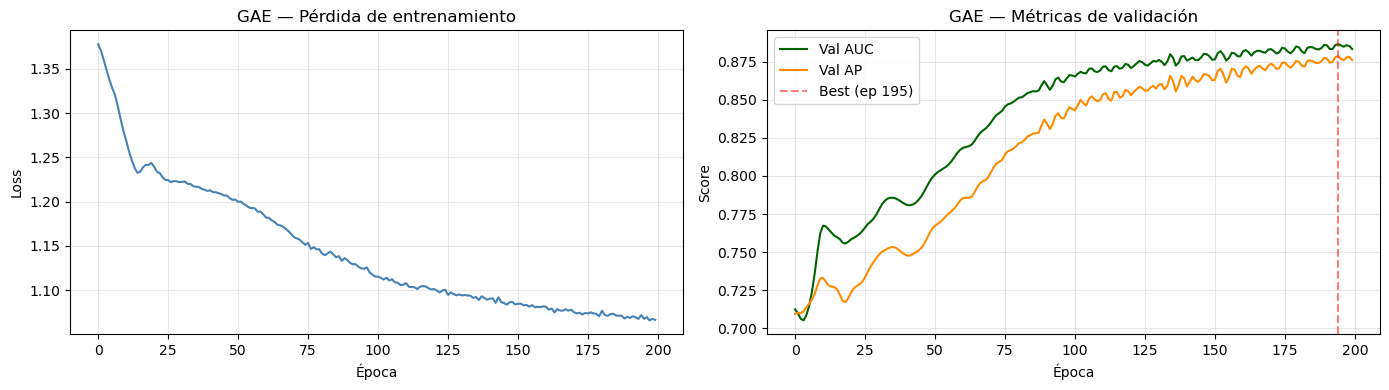

In [8]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_gae['loss'], color='steelblue')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('GAE — Pérdida de entrenamiento')
axes[0].grid(alpha=0.3)

axes[1].plot(history_gae['val_auc'], label='Val AUC', color='darkgreen')
axes[1].plot(history_gae['val_ap'],  label='Val AP',  color='darkorange')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_epoch})')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Score')
axes[1].set_title('GAE — Métricas de validación')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Cálculo de anomaly scores (GAE)
Una vez entrenado el GAE, calculamos dos scores de anomalía por nodo, tal como acordamos:
### 5.1 Score 1 — Error de reconstrucción de adyacenciaPara cada nodo $i$, comparamos su fila real de la matriz de adyacencia $A_i$ con su fila reconstruida $\hat{A}_i = \sigma(Z z_i^T)$. Usamos **BCE** entre ambos:$$s^{rec}_i = -\frac{1}{N}\sum_{j} A_{ij} \log \hat{A}_{ij} + (1 - A_{ij}) \log(1 - \hat{A}_{ij})$$Un nodo cuyo patrón de conexiones no se reconstruye bien tiene un score alto.**Implementación eficiente:** la matriz de adyacencia completa $A$ es 11.371 × 11.371 (~129M entradas) — viable en memoria pero sólo si usamos representaciones densas con cuidado. El cálculo se vectoriza por bloques de filas para no agotar memoria.### 5.2 Score 2 — Norma del embedding latenteLa intuición de este score es distinta: un nodo "bien comportado" debería caer cerca del centro del espacio latente, donde se concentran los patrones aprendidos por el modelo. Los nodos cuyos embeddings se alejan del centro de masas son potencialmente anómalos.$$s^{lat}_i = \| z_i - \bar{z} \|_2$$donde $\bar{z}$ es el centroide de todos los embeddings. Esta interpretación está alineada con la literatura clásica de detección de outliers en espacios euclídeos.Calcularemos ambos y compararemos cuál discrimina mejor las anomalías candidatas identificadas en el EDA.

In [9]:
@torch.no_grad()
def get_embeddings(model, data):
    """Devuelve los embeddings latentes Z usando todas las aristas de entrenamiento."""
    model.eval()
    z = model.encode(data.x, data.edge_index)
    return z


@torch.no_grad()
def reconstruction_error_per_node(z, edge_index, num_nodes, batch_size=512):
    """
    Calcula el error de reconstrucción BCE por nodo, vectorizado por bloques.

    z: embeddings [N, D]
    edge_index: aristas reales del grafo (formato dirigido, ambas direcciones)
    num_nodes: N
    batch_size: nº de filas procesadas por bloque para controlar memoria
    """
    device_z = z.device
    # Construimos un set de aristas reales para reconstruir A_i por filas
    src, dst = edge_index[0], edge_index[1]

    errors = torch.zeros(num_nodes, device=device_z)

    for start in range(0, num_nodes, batch_size):
        end = min(start + batch_size, num_nodes)
        # Embedding de los nodos de este bloque [B, D]
        z_block = z[start:end]
        # Producto interno con todos los nodos -> logits [B, N]
        logits = z_block @ z.t()
        # Targets: A[i,j] = 1 si (i,j) es arista, 0 si no
        targets = torch.zeros_like(logits)
        # Marcamos en targets las aristas que parten de los nodos del bloque
        mask = (src >= start) & (src < end)
        local_src = src[mask] - start
        local_dst = dst[mask]
        targets[local_src, local_dst] = 1.0
        # BCE por elemento, promediado por fila
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        errors[start:end] = bce.mean(dim=1)

    return errors.cpu().numpy()


# Calculamos embeddings con el modelo final (cargado con best_state)
z_gae = get_embeddings(model_gae, train_data)
print(f'Embeddings shape: {z_gae.shape}')

# Score 1: error de reconstrucción por nodo
# Usamos el edge_index original COMPLETO del grafo (no solo train) para la evaluación
# porque queremos saber qué tan bien el modelo reconstruye todas las conexiones reales
full_edge_index = data_M.edge_index.to(device)
recon_err_gae = reconstruction_error_per_node(z_gae, full_edge_index, data_M.num_nodes)
print(f'Reconstruction error — min={recon_err_gae.min():.4f}, max={recon_err_gae.max():.4f}, mean={recon_err_gae.mean():.4f}')

# Score 2: distancia del embedding al centroide
z_np = z_gae.cpu().numpy()
centroid = z_np.mean(axis=0)
latent_dist_gae = np.linalg.norm(z_np - centroid, axis=1)
print(f'Latent distance   — min={latent_dist_gae.min():.4f}, max={latent_dist_gae.max():.4f}, mean={latent_dist_gae.mean():.4f}')

Embeddings shape: torch.Size([11371, 16])
Reconstruction error — min=0.6024, max=1.4096, mean=0.7874
Latent distance   — min=0.1750, max=8.2617, mean=1.2119


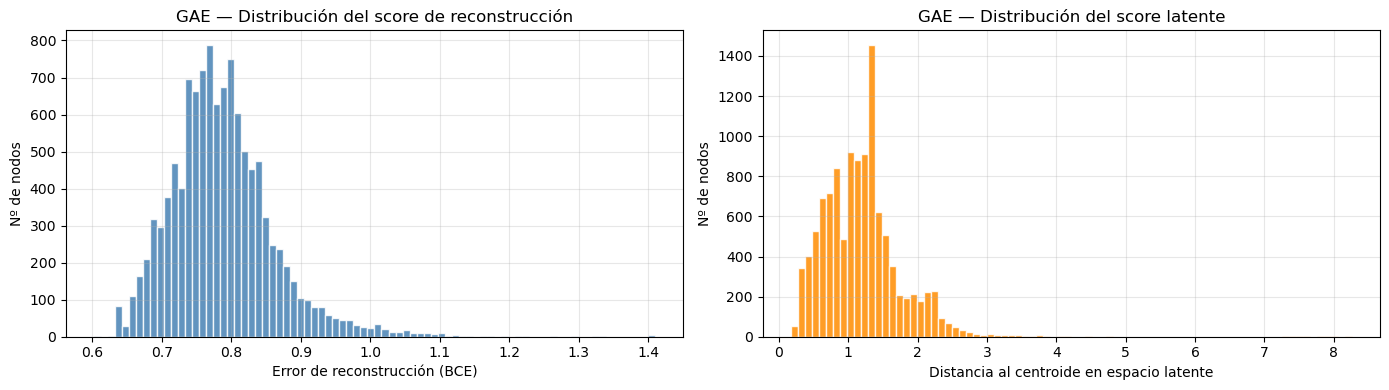

In [10]:
# Visualización de las distribuciones de scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(recon_err_gae, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Error de reconstrucción (BCE)')
axes[0].set_ylabel('Nº de nodos')
axes[0].set_title('GAE — Distribución del score de reconstrucción')
axes[0].grid(alpha=0.3)

axes[1].hist(latent_dist_gae, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Distancia al centroide en espacio latente')
axes[1].set_ylabel('Nº de nodos')
axes[1].set_title('GAE — Distribución del score latente')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

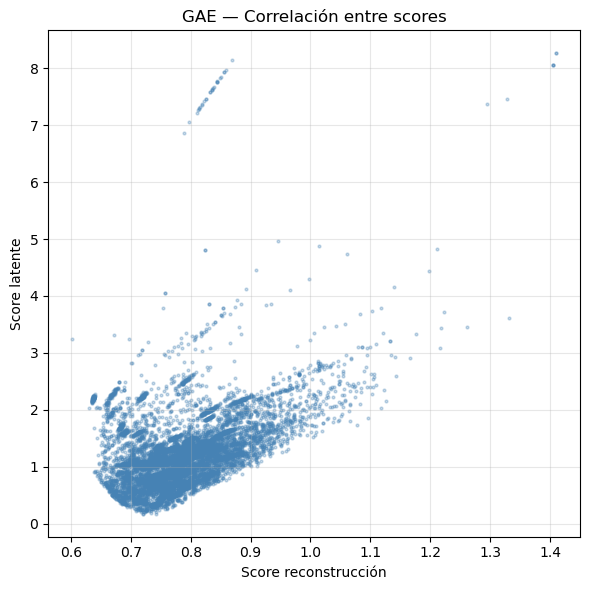

Pearson r = 0.4431


In [11]:
# Correlación entre los dos scores del GAE
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(recon_err_gae, latent_dist_gae, s=4, alpha=0.3, color='steelblue')
ax.set_xlabel('Score reconstrucción')
ax.set_ylabel('Score latente')
ax.set_title('GAE — Correlación entre scores')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = np.corrcoef(recon_err_gae, latent_dist_gae)[0, 1]
print(f'Pearson r = {corr:.4f}')

## 6. Arquitectura y entrenamiento del VGAE### 6.1 Fundamento teóricoEl **Variational Graph Autoencoder** (Kipf & Welling, 2016) sustituye el embedding determinista por una **distribución gaussiana**: cada nodo no se proyecta a un punto $z_i$ sino a una distribución $q(z_i \mid X, A) = \mathcal{N}(\mu_i, \text{diag}(\sigma_i^2))$.El encoder produce ahora dos vectores por nodo: la media $\mu_i$ y el log-varianza $\log \sigma_i^2$. El embedding se obtiene por el **truco de reparametrización**:$$z_i = \mu_i + \sigma_i \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$La pérdida añade un término de regularización **KL-divergence** que empuja la distribución posterior aprendida hacia un prior gaussiano estándar:$$\mathcal{L}_{VGAE} = \mathcal{L}_{rec} + \frac{1}{N} \text{KL}[q(Z \mid X, A) \| p(Z)]$$### 6.2 Diferencias prácticas con el GAE- **Espacio latente más estructurado:** la regularización KL fuerza a que el espacio latente sea continuo y suave, lo que típicamente mejora la generalización.- **Detección de anomalías:** las distribuciones aprendidas para nodos anómalos suelen tener varianzas mayores (el modelo es menos seguro de su representación), lo que aporta un score adicional.- **Coste:** ligeramente superior al GAE pero del mismo orden.

In [12]:
class VariationalGCNEncoder(nn.Module):
    """
    Encoder variacional: dos capas GCN compartidas y dos cabezas finales,
    una para mu y otra para logvar.
    """
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv_shared = GCNConv(in_channels, hidden_channels, cached=True)
        self.conv_mu     = GCNConv(hidden_channels, out_channels, cached=True)
        self.conv_logvar = GCNConv(hidden_channels, out_channels, cached=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv_shared(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        mu     = self.conv_mu(x, edge_index)
        logvar = self.conv_logvar(x, edge_index)
        return mu, logvar


# Reseteamos seeds para que el VGAE empiece en condiciones equivalentes al GAE
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model_vgae = VGAE(VariationalGCNEncoder(IN_DIM, HIDDEN_DIM, LATENT_DIM)).to(device)
print(model_vgae)

VGAE(
  (encoder): VariationalGCNEncoder(
    (conv_shared): GCNConv(3, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logvar): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
)


In [13]:
def train_epoch_vgae(model, data, optimizer):
    """Una época de entrenamiento del VGAE: BCE de reconstrucción + KL."""
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.pos_edge_label_index)
    # 1/N normaliza el término KL respecto al número de nodos
    kl_loss = (1 / data.num_nodes) * model.kl_loss()
    total_loss = loss + kl_loss
    total_loss.backward()
    optimizer.step()
    return float(total_loss), float(loss), float(kl_loss)


@torch.no_grad()
def eval_split_vgae(model, data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    auc, ap = model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)
    return auc, ap

In [14]:
optimizer_vgae = torch.optim.Adam(model_vgae.parameters(), lr=LR)

history_vgae = {'loss': [], 'rec': [], 'kl': [], 'val_auc': [], 'val_ap': []}
best_val_auc_v = 0.0
best_epoch_v = 0
patience_counter = 0
best_state_v = None

for epoch in range(1, EPOCHS + 1):
    total, rec, kl = train_epoch_vgae(model_vgae, train_data, optimizer_vgae)
    val_auc, val_ap = eval_split_vgae(model_vgae, val_data)

    history_vgae['loss'].append(total)
    history_vgae['rec'].append(rec)
    history_vgae['kl'].append(kl)
    history_vgae['val_auc'].append(val_auc)
    history_vgae['val_ap'].append(val_ap)

    if val_auc > best_val_auc_v:
        best_val_auc_v = val_auc
        best_epoch_v = epoch
        patience_counter = 0
        best_state_v = {k: v.detach().clone() for k, v in model_vgae.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Total {total:.4f} | Rec {rec:.4f} | KL {kl:.4f} | '
              f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}. Mejor época: {best_epoch_v} (Val AUC {best_val_auc_v:.4f})')
        break

if best_state_v is not None:
    model_vgae.load_state_dict(best_state_v)

test_auc_v, test_ap_v = eval_split_vgae(model_vgae, test_data)
print(f'\n=== Resultados finales VGAE ===')
print(f'Test AUC: {test_auc_v:.4f}')
print(f'Test AP : {test_ap_v:.4f}')

Epoch   1 | Total 3.4821 | Rec 3.4821 | KL 0.0000 | Val AUC 0.7516 | Val AP 0.7026
Epoch  10 | Total 2.3487 | Rec 2.3486 | KL 0.0001 | Val AUC 0.7596 | Val AP 0.7398
Epoch  20 | Total 1.4235 | Rec 1.4228 | KL 0.0007 | Val AUC 0.7790 | Val AP 0.7441
Epoch  30 | Total 1.2649 | Rec 1.2634 | KL 0.0015 | Val AUC 0.7776 | Val AP 0.7347
Epoch  40 | Total 1.2282 | Rec 1.2262 | KL 0.0021 | Val AUC 0.8000 | Val AP 0.7615
Epoch  50 | Total 1.2064 | Rec 1.2040 | KL 0.0024 | Val AUC 0.8108 | Val AP 0.7800
Epoch  60 | Total 1.1897 | Rec 1.1871 | KL 0.0026 | Val AUC 0.8213 | Val AP 0.7926
Epoch  70 | Total 1.1706 | Rec 1.1679 | KL 0.0027 | Val AUC 0.8330 | Val AP 0.8081
Epoch  80 | Total 1.1543 | Rec 1.1515 | KL 0.0028 | Val AUC 0.8450 | Val AP 0.8240
Epoch  90 | Total 1.1337 | Rec 1.1308 | KL 0.0029 | Val AUC 0.8562 | Val AP 0.8377
Epoch 100 | Total 1.1216 | Rec 1.1186 | KL 0.0031 | Val AUC 0.8666 | Val AP 0.8485
Epoch 110 | Total 1.1143 | Rec 1.1111 | KL 0.0032 | Val AUC 0.8668 | Val AP 0.8491
Epoc

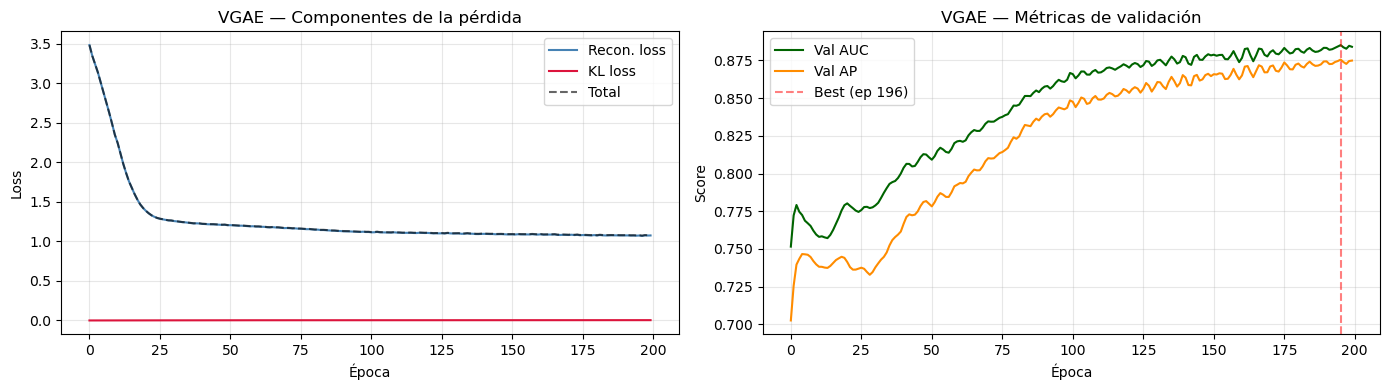

In [15]:
# Curvas de entrenamiento del VGAE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_vgae['rec'], label='Recon. loss', color='steelblue')
axes[0].plot(history_vgae['kl'],  label='KL loss',     color='crimson')
axes[0].plot(history_vgae['loss'], label='Total',       color='black', linestyle='--', alpha=0.6)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('VGAE — Componentes de la pérdida')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_vgae['val_auc'], label='Val AUC', color='darkgreen')
axes[1].plot(history_vgae['val_ap'],  label='Val AP',  color='darkorange')
axes[1].axvline(best_epoch_v - 1, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_epoch_v})')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Score')
axes[1].set_title('VGAE — Métricas de validación')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Anomaly scores (VGAE)
Repetimos el cálculo de los dos scores con el VGAE. En el caso del score latente, podríamos usar la media $\mu_i$ o una muestra de la distribución — usamos $\mu_i$ por ser la representación determinista más estable.

In [16]:
@torch.no_grad()
def get_embeddings_vgae(model, data, use_mu=True):
    """
    Devuelve los embeddings latentes del VGAE.
    Por defecto usamos mu (más estable que muestrear).
    """
    model.eval()
    z = model.encode(data.x, data.edge_index)
    # Cuando model.training=False, model.encode devuelve mu directamente en VGAE
    # pero verificamos accediendo al encoder
    return z


z_vgae = get_embeddings_vgae(model_vgae, train_data)
print(f'VGAE embeddings shape: {z_vgae.shape}')

# Score 1: error de reconstrucción
recon_err_vgae = reconstruction_error_per_node(z_vgae, full_edge_index, data_M.num_nodes)
print(f'Reconstruction error — min={recon_err_vgae.min():.4f}, max={recon_err_vgae.max():.4f}, mean={recon_err_vgae.mean():.4f}')

# Score 2: distancia al centroide
z_vgae_np = z_vgae.cpu().numpy()
centroid_v = z_vgae_np.mean(axis=0)
latent_dist_vgae = np.linalg.norm(z_vgae_np - centroid_v, axis=1)
print(f'Latent distance   — min={latent_dist_vgae.min():.4f}, max={latent_dist_vgae.max():.4f}, mean={latent_dist_vgae.mean():.4f}')

VGAE embeddings shape: torch.Size([11371, 16])
Reconstruction error — min=0.6292, max=1.3710, mean=0.7845
Latent distance   — min=0.1832, max=6.6510, mean=1.1948


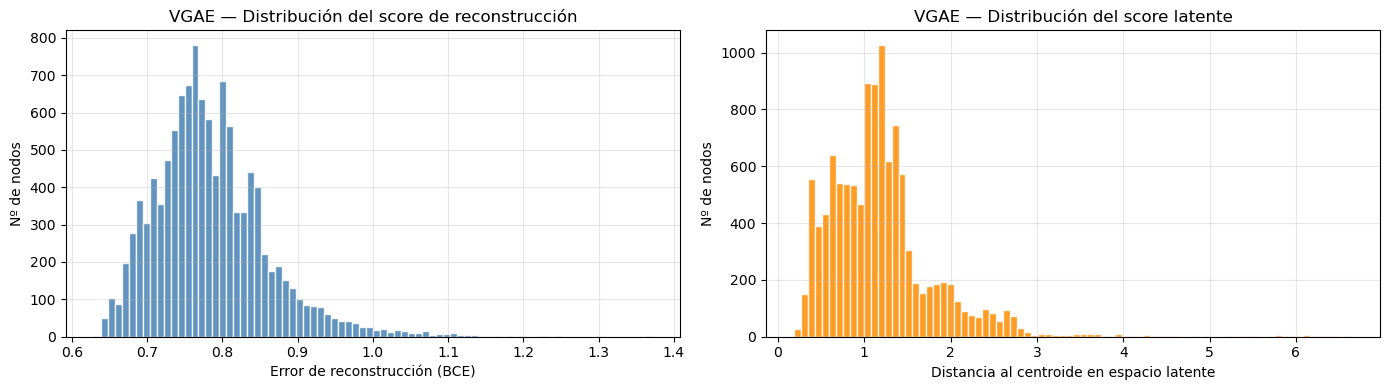

In [17]:
# Distribuciones VGAE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(recon_err_vgae, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Error de reconstrucción (BCE)')
axes[0].set_ylabel('Nº de nodos')
axes[0].set_title('VGAE — Distribución del score de reconstrucción')
axes[0].grid(alpha=0.3)

axes[1].hist(latent_dist_vgae, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Distancia al centroide en espacio latente')
axes[1].set_ylabel('Nº de nodos')
axes[1].set_title('VGAE — Distribución del score latente')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Comparativa GAE vs VGAE
Comparamos los dos modelos en tres dimensiones:1. **Métricas de evaluación** (AUC, AP en test).2. **Correlación entre los rankings** de anomalía: ¿identifican los mismos nodos como anómalos?3. **Solapamiento del top-K**: de los 100 nodos más anómalos según cada modelo, ¿cuántos coinciden?

In [18]:
# Tabla comparativa de métricas
metrics_df = pd.DataFrame({
    'Modelo':   ['GAE', 'VGAE'],
    'Test AUC': [test_auc, test_auc_v],
    'Test AP':  [test_ap,  test_ap_v],
    'Best epoch': [best_epoch, best_epoch_v],
})
print('=== Comparativa de modelos ===')
print(metrics_df.to_string(index=False))

=== Comparativa de modelos ===
Modelo  Test AUC  Test AP  Best epoch
   GAE  0.883049 0.874712         195
  VGAE  0.882139 0.872478         196


In [19]:
from scipy.stats import spearmanr

# Correlación de rankings entre scores
def rank_corr(s1, s2):
    rho, _ = spearmanr(s1, s2)
    return rho

print('=== Correlación de rankings (Spearman) ===')
print(f'GAE-rec   vs VGAE-rec  : {rank_corr(recon_err_gae,   recon_err_vgae):.4f}')
print(f'GAE-lat   vs VGAE-lat  : {rank_corr(latent_dist_gae, latent_dist_vgae):.4f}')
print(f'GAE-rec   vs GAE-lat   : {rank_corr(recon_err_gae,   latent_dist_gae):.4f}')
print(f'VGAE-rec  vs VGAE-lat  : {rank_corr(recon_err_vgae,  latent_dist_vgae):.4f}')

=== Correlación de rankings (Spearman) ===
GAE-rec   vs VGAE-rec  : 0.9656
GAE-lat   vs VGAE-lat  : 0.9779
GAE-rec   vs GAE-lat   : 0.4565
VGAE-rec  vs VGAE-lat  : 0.3385


In [20]:
# Solapamiento del top-K entre modelos
def top_k_overlap(s1, s2, k=100):
    top1 = set(np.argsort(-s1)[:k])
    top2 = set(np.argsort(-s2)[:k])
    return len(top1 & top2) / k

K = 100
print(f'=== Solapamiento del top-{K} ===')
print(f'GAE-rec   vs VGAE-rec : {top_k_overlap(recon_err_gae,   recon_err_vgae,   K):.2%}')
print(f'GAE-lat   vs VGAE-lat : {top_k_overlap(latent_dist_gae, latent_dist_vgae, K):.2%}')
print(f'GAE-rec   vs GAE-lat  : {top_k_overlap(recon_err_gae,   latent_dist_gae,  K):.2%}')
print(f'VGAE-rec  vs VGAE-lat : {top_k_overlap(recon_err_vgae,  latent_dist_vgae, K):.2%}')

=== Solapamiento del top-100 ===
GAE-rec   vs VGAE-rec : 85.00%
GAE-lat   vs VGAE-lat : 71.00%
GAE-rec   vs GAE-lat  : 22.00%
VGAE-rec  vs VGAE-lat : 17.00%


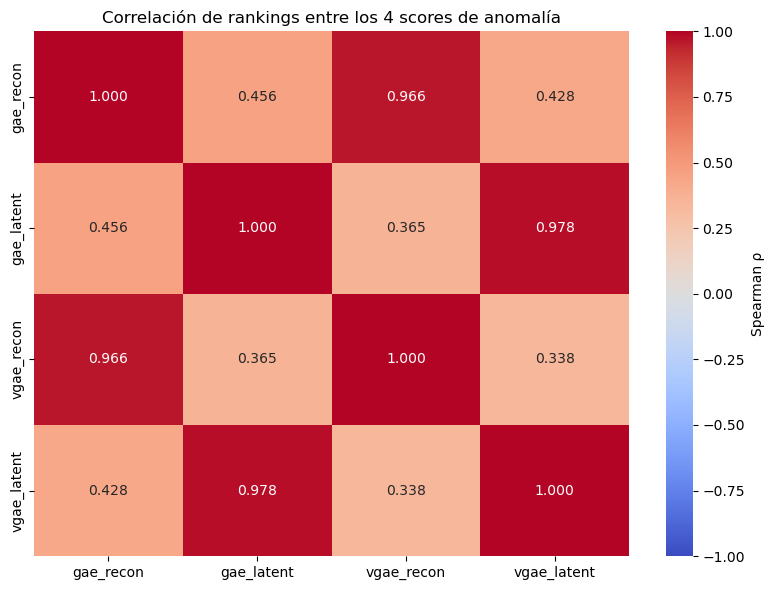

In [21]:
# Visualización conjunta de los cuatro scores normalizados
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

scores_df = pd.DataFrame({
    'gae_recon':   normalize(recon_err_gae),
    'gae_latent':  normalize(latent_dist_gae),
    'vgae_recon':  normalize(recon_err_vgae),
    'vgae_latent': normalize(latent_dist_vgae),
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(scores_df.corr(method='spearman'), annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, fmt='.3f', cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Correlación de rankings entre los 4 scores de anomalía')
plt.tight_layout()
plt.show()

## 9. Análisis de anomalías detectadas
Construimos una tabla de scores por nodo y la cruzamos con `meta_members` para interpretar los resultados. El EDA del grafo M identificó varios candidatos a anomalía estructural — verificamos si alguno aparece en el top-K de los modelos:- **13 nodos hoja** (grado = 1), entre ellos *GEEK by AKEIN Engineering*.- **97 super-conectores** (grado > 1.000), liderados por Jim H y Shalini.- **Pablo** — alta betweenness con degree moderada (puente estructural).- **Microcomunidades C2 (13 nodos) y C21 (6 nodos)**.- **487 nodos puente** con ratio inter-comunidad > 0.5.

In [22]:
# Construimos un DataFrame con todos los scores por nodo
member_ids_M = data_M.member_ids  # lista de member_id en el orden de los índices del grafo

scores_full = pd.DataFrame({
    'idx':         np.arange(data_M.num_nodes),
    'member_id':   member_ids_M,
    'gae_recon':   recon_err_gae,
    'gae_latent':  latent_dist_gae,
    'vgae_recon':  recon_err_vgae,
    'vgae_latent': latent_dist_vgae,
})

# Calculamos también el grado de cada nodo en el grafo original
degree = torch.zeros(data_M.num_nodes, dtype=torch.long)
degree.scatter_add_(0, data_M.edge_index[0].cpu(), torch.ones(data_M.edge_index.shape[1], dtype=torch.long))
scores_full['degree'] = degree.numpy() // 2  # /2 porque cada arista está duplicada en edge_index

# Cruzamos con meta_members
scores_full = scores_full.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    on='member_id', how='left'
)

print(f'Shape: {scores_full.shape}')
scores_full.head()

Shape: (11371, 10)


,idx,member_id,gae_recon,gae_latent,vgae_recon,vgae_latent,degree,name,city,state
0,0,2069,0.883628,1.046555,0.899726,1.093538,219,Wesley Duffee-Braun,Brentwood,TN
1,1,8386,0.906803,1.231379,0.882591,1.142521,307,Tim,Nashville,TN
2,2,9205,0.917146,1.367175,0.930247,1.361916,334,Brenda,Brentwood,TN
3,3,42506,0.740550,0.675989,0.744830,0.613798,122,Chris Meador,Nashville,TN
4,4,106758,0.814851,1.218721,0.810673,1.143270,119,Kt,Antioch,TN


In [23]:
# Top 20 anómalos según GAE - reconstrucción
print('=== Top 20 — GAE reconstruction error ===')
top20_gae_rec = scores_full.nlargest(20, 'gae_recon')[
    ['member_id', 'name', 'city', 'state', 'degree', 'gae_recon']
]
print(top20_gae_rec.to_string(index=False))

=== Top 20 — GAE reconstruction error ===
 member_id                  name            city state  degree  gae_recon
   4184723                 Peggy  Hendersonville    TN       3   1.409647
  79152872          Holly Miller       Hermitage    TN       3   1.409647
   9728295          Sue Knuckles       Nashville    TN       3   1.405301
 151916002     Christine Jackson       Nashville    TN       3   1.405301
 217882384         Kristie Meyer          Renton    WA       3   1.405301
   3949436                 Pablo       Nashville    TN     688   1.331540
   6944107                Joan D       Nashville    TN       3   1.327740
 223167558         Georgia Nejus  Goodlettsville    TN       3   1.294413
   5900662         Matt Kenigson       Nashville    TN     905   1.261297
 223204425                    RJ       Nashville    TN       1   1.222886
   8539046               Shalini       Nashville    TN     955   1.218382
 126066112 Taylor Michael Matson       Nashville    TN     731   1.215

In [24]:
# Top 20 anómalos según GAE - latent distance
print('=== Top 20 — GAE latent distance ===')
top20_gae_lat = scores_full.nlargest(20, 'gae_latent')[
    ['member_id', 'name', 'city', 'state', 'degree', 'gae_latent']
]
print(top20_gae_lat.to_string(index=False))

=== Top 20 — GAE latent distance ===
 member_id              name              city state  degree  gae_latent
   4184723             Peggy    Hendersonville    TN       3    8.261728
  79152872      Holly Miller         Hermitage    TN       3    8.261728
 195697902    Chelsea Siegel           Chicago    IL      19    8.138134
   9728295      Sue Knuckles         Nashville    TN       3    8.057983
 151916002 Christine Jackson         Nashville    TN       3    8.057983
 217882384     Kristie Meyer            Renton    WA       3    8.057983
  13486911      Dennis McGee           Chicago    IL      19    7.976515
  83080482        Jacqueline           Chicago    IL      19    7.930310
 187005263          Mellissa           Chicago    IL      19    7.929716
  88902572     Ryan Modreske           Chicago    IL      19    7.841447
 157219632         Neel Goel           Chicago    IL      19    7.821751
 173427802      Sarah Galvin          Oak Lawn    IL      19    7.771914
 184141812    

In [25]:
# Top 20 anómalos según VGAE - reconstrucción
print('=== Top 20 — VGAE reconstruction error ===')
top20_vgae_rec = scores_full.nlargest(20, 'vgae_recon')[
    ['member_id', 'name', 'city', 'state', 'degree', 'vgae_recon']
]
print(top20_vgae_rec.to_string(index=False))

=== Top 20 — VGAE reconstruction error ===
 member_id                  name      city state  degree  vgae_recon
   3949436                 Pablo Nashville    TN     688    1.370979
   5900662         Matt Kenigson Nashville    TN     905    1.301066
 126066112 Taylor Michael Matson Nashville    TN     731    1.248010
   8539046               Shalini Nashville    TN     955    1.231146
 206481851           Adia Tigney Nashville    TN     638    1.195742
  15446041     Samuel Palaparthy Nashville    TN     771    1.178831
 127214502       Bryan P Marlowe    Smyrna    TN     639    1.160019
  81924252               Theresa Nashville    TN     887    1.157368
 138867992            Trent Hand Nashville    TN     588    1.144184
  60195472     Karthik Kornalies Nashville    TN     560    1.139330
  49816142            Kim Higdon Nashville    TN     448    1.138207
  11149295           Zack Benner Nashville    TN     571    1.134960
 203244569             Calvin J.   Antioch    TN     605    

In [26]:
# Top 20 anómalos según VGAE - latent distance
print('=== Top 20 — VGAE latent distance ===')
top20_vgae_lat = scores_full.nlargest(20, 'vgae_latent')[
    ['member_id', 'name', 'city', 'state', 'degree', 'vgae_latent']
]
print(top20_vgae_lat.to_string(index=False))

=== Top 20 — VGAE latent distance ===
 member_id              name           city state  degree  vgae_latent
 204309536 John Ryan Kitchen       Brisbane   NaN       9     6.651015
   4184723             Peggy Hendersonville    TN       3     6.461708
  79152872      Holly Miller      Hermitage    TN       3     6.461708
 195697902    Chelsea Siegel        Chicago    IL      19     6.394298
   9728295      Sue Knuckles      Nashville    TN       3     6.286936
 151916002 Christine Jackson      Nashville    TN       3     6.286936
 217882384     Kristie Meyer         Renton    WA       3     6.286936
  13486911      Dennis McGee        Chicago    IL      19     6.266890
 187005263          Mellissa        Chicago    IL      19     6.238572
  83080482        Jacqueline        Chicago    IL      19     6.237275
  88902572     Ryan Modreske        Chicago    IL      19     6.166844
 157219632         Neel Goel        Chicago    IL      19     6.153752
 184141812           Ricardo        Chi

In [27]:
# Verificación: ¿los nodos hoja (grado=1) salen como anómalos?
leaf_nodes = scores_full[scores_full['degree'] == 1]
print(f'Nodos hoja en el dataset: {len(leaf_nodes)}')
print('\n=== Posición de cada nodo hoja en el ranking de cada score ===')
for _, row in leaf_nodes.iterrows():
    rank_gr = (scores_full['gae_recon']   > row['gae_recon']).sum()   + 1
    rank_gl = (scores_full['gae_latent']  > row['gae_latent']).sum()  + 1
    rank_vr = (scores_full['vgae_recon']  > row['vgae_recon']).sum()  + 1
    rank_vl = (scores_full['vgae_latent'] > row['vgae_latent']).sum() + 1
    print(f"  {row['name'][:30]:30s} | GAE-rec #{rank_gr:5d} | GAE-lat #{rank_gl:5d} | "
          f"VGAE-rec #{rank_vr:5d} | VGAE-lat #{rank_vl:5d}")

Nodos hoja en el dataset: 54

=== Posición de cada nodo hoja en el ranking de cada score ===
  paulrsmith                     | GAE-rec #10437 | GAE-lat # 5280 | VGAE-rec #10504 | VGAE-lat # 5551
  rbedwell                       | GAE-rec # 2305 | GAE-lat # 1272 | VGAE-rec # 3004 | VGAE-lat # 1794
  Micah Redding                  | GAE-rec # 9489 | GAE-lat #11370 | VGAE-rec # 9133 | VGAE-lat #11367
  Gabriel                        | GAE-rec # 9490 | GAE-lat #11370 | VGAE-rec # 9133 | VGAE-lat #11367
  Dominique                      | GAE-rec #   28 | GAE-lat #  110 | VGAE-rec #   70 | VGAE-lat #  222
  Chris Mule'                    | GAE-rec #10619 | GAE-lat #  378 | VGAE-rec #10405 | VGAE-lat #  533
  Ari                            | GAE-rec # 4216 | GAE-lat # 1638 | VGAE-rec # 4954 | VGAE-lat # 2273
  Patricia                       | GAE-rec # 4764 | GAE-lat # 5278 | VGAE-rec # 5633 | VGAE-lat # 4304
  Aaron Farris                   | GAE-rec #10680 | GAE-lat #  801 | VGAE-rec #1072

In [28]:
# Verificación: ¿los super-conectores (grado > 1000) salen como anómalos?
super_nodes = scores_full[scores_full['degree'] > 1000].sort_values('degree', ascending=False)
print(f'Super-conectores: {len(super_nodes)}')
print('\n=== Top 10 super-conectores y su ranking de anomalía ===')
for _, row in super_nodes.head(10).iterrows():
    rank_gr = (scores_full['gae_recon']   > row['gae_recon']).sum()   + 1
    rank_gl = (scores_full['gae_latent']  > row['gae_latent']).sum()  + 1
    rank_vr = (scores_full['vgae_recon']  > row['vgae_recon']).sum()  + 1
    rank_vl = (scores_full['vgae_latent'] > row['vgae_latent']).sum() + 1
    print(f"  {row['name'][:25]:25s} | grado {row['degree']:5d} | "
          f"GAE-rec #{rank_gr:5d} | GAE-lat #{rank_gl:5d} | "
          f"VGAE-rec #{rank_vr:5d} | VGAE-lat #{rank_vl:5d}")

Super-conectores: 1

=== Top 10 super-conectores y su ranking de anomalía ===
  Jim H                     | grado  1178 | GAE-rec #   50 | GAE-lat #   66 | VGAE-rec #   38 | VGAE-lat #   77


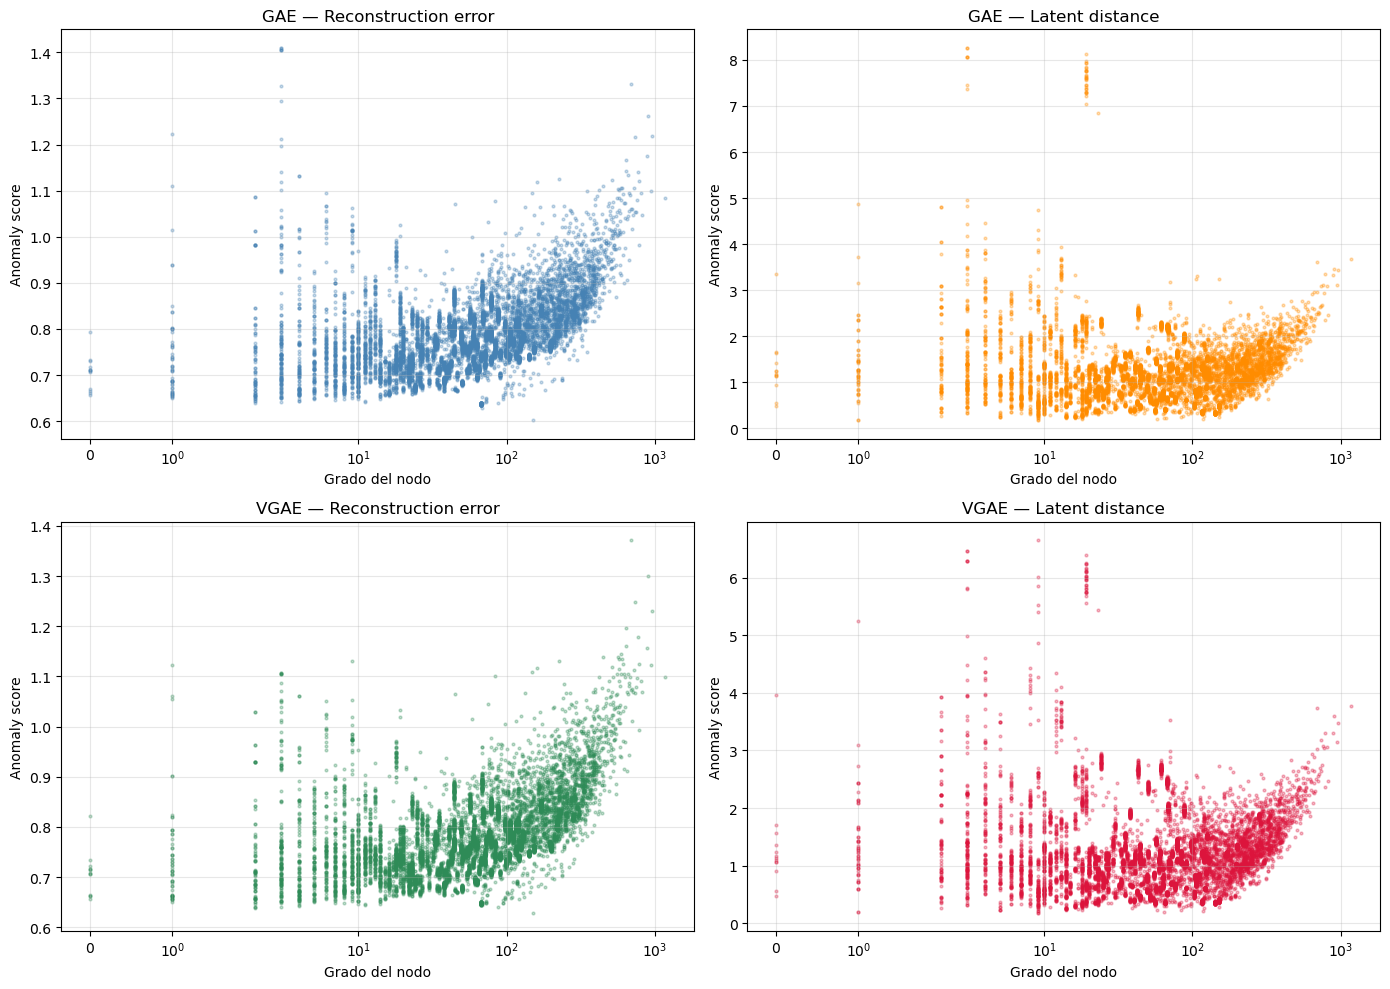

In [29]:
# Visualización: scatter degree vs cada score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatters = [
    ('gae_recon',   'GAE — Reconstruction error',   axes[0, 0], 'steelblue'),
    ('gae_latent',  'GAE — Latent distance',        axes[0, 1], 'darkorange'),
    ('vgae_recon',  'VGAE — Reconstruction error',  axes[1, 0], 'seagreen'),
    ('vgae_latent', 'VGAE — Latent distance',       axes[1, 1], 'crimson'),
]

for col, title, ax, color in scatters:
    ax.scatter(scores_full['degree'], scores_full[col], s=4, alpha=0.3, color=color)
    ax.set_xlabel('Grado del nodo')
    ax.set_ylabel('Anomaly score')
    ax.set_title(title)
    ax.set_xscale('symlog')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Guardado de resultadosGuardamos:- La tabla completa de scores por nodo (`scores_M.csv`) — para cruzar con los otros grafos en la sección de discusión del TFM.- Los embeddings latentes de ambos modelos (`embeddings_M.npz`).- El historial de entrenamiento (`history_M.json`) — para reproducir las gráficas de la memoria sin reentrenar.

In [30]:
# CSV de scores por nodo
scores_full.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)
print(f'Guardado: {RESULTS_PATH}scores_M.csv  ({scores_full.shape})')

# Embeddings
np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_M.npz'),
    z_gae=z_np,
    z_vgae=z_vgae_np,
    member_ids=np.array(member_ids_M),
)
print(f'Guardado: {RESULTS_PATH}embeddings_M.npz')

# Historial de entrenamiento
import json
history_export = {
    'gae': {k: list(map(float, v)) for k, v in history_gae.items()},
    'vgae': {k: list(map(float, v)) for k, v in history_vgae.items()},
    'metrics': {
        'gae':  {'test_auc': float(test_auc),   'test_ap': float(test_ap),   'best_epoch': int(best_epoch)},
        'vgae': {'test_auc': float(test_auc_v), 'test_ap': float(test_ap_v), 'best_epoch': int(best_epoch_v)},
    },
    'config': {
        'hidden_dim': HIDDEN_DIM, 'latent_dim': LATENT_DIM,
        'lr': LR, 'epochs': EPOCHS, 'patience': PATIENCE, 'seed': SEED,
    }
}
with open(os.path.join(RESULTS_PATH, 'history_M.json'), 'w') as f:
    json.dump(history_export, f, indent=2)
print(f'Guardado: {RESULTS_PATH}history_M.json')

Guardado: ../data/results/scores_M.csv  ((11371, 10))
Guardado: ../data/results/embeddings_M.npz
Guardado: ../data/results/history_M.json


## Resumen del notebookEn este notebook hemos:1. **Entrenado un GAE** sobre el grafo de miembros con un encoder GCN de 2 capas (32 → 16) y un decoder de producto interno.2. **Entrenado un VGAE** con la misma arquitectura base pero con encoder variacional.3. **Calculado dos scores de anomalía por modelo**: error de reconstrucción de adyacencia y distancia al centroide en el espacio latente.4. **Comparado los rankings** mediante correlación de Spearman y solapamiento del top-K.5. **Analizado los nodos más anómalos** y verificado si los candidatos identificados en el EDA (nodos hoja, super-conectores) aparecen efectivamente en lo alto del ranking.Los resultados quedan guardados en `data/results/` para su uso en los notebooks 05b (grafo G), 05c (grafo MG) y en la sección de discusión del TFM.